In [13]:
# =============================================================
# SEL 1: SETUP, KONFIGURASI, DAN PUSAT FUSI (FINAL v3)
# =============================================================

# --- Instalasi dan Impor Library ---
print("📦 Menginstal/Memeriksa library yang dibutuhkan...");
!pip install ultralytics pandas openpyxl -q
import os, cv2, pandas as pd, time, numpy as np, matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import drive
print("✅ Library berhasil diimpor.")
drive.mount('/content/drive'); print("✅ Google Drive berhasil terhubung.")

# --- KONFIGURASI GLOBAL ---
print("\n⚙️ Memuat konfigurasi global...")
PATH_MODEL_TERBAIK = 'yolov8l.pt'
PATH_FOLDER_OUTPUT = '/content/drive/MyDrive/Magang KP Model AI/Model Anomaly - Crowd/Hasil Akhir Profesional/'
os.makedirs(PATH_FOLDER_OUTPUT, exist_ok=True)
# --- Parameter Tuning Utama ---
GRID_ROWS,GRID_COLS=4,5; CROWD_THRESHOLD_PER_CELL=2; ANOMALY_DURATION_SECONDS=3; MIN_ANOMALY_CELLS_FOR_ALARM=1;
CONFIDENCE_THRESHOLD=0.4; IMG_SIZE=640; GRACE_PERIOD_FRAMES=10

# --- Pemuatan Model (Dibuat Global) ---
try:
    model=YOLO(PATH_MODEL_TERBAIK); person_class_id=[k for k, v in model.names.items() if v.lower() == 'person'][0]
    print(f"✅ Model '{PATH_MODEL_TERBAIK}' dimuat."); print(f"   - Folder output: {PATH_FOLDER_OUTPUT}")
except Exception as e: print(f"❌ Gagal memuat model: {e}"); exit()

# =================================================================
# === PUSAT FUNGSI (Dengan Perbaikan Logika Waktu) ===
# =================================================================

def process_single_frame(frame, time_reference, state_vars):
    """
    Fungsi inti yang memproses satu frame video.
    Menggunakan `time_reference` (bisa time.time() atau waktu video) untuk menghitung durasi.
    """
    annotated_frame = frame.copy()
    cell_start_time, cell_grace_counter = state_vars
    detections = model.predict(annotated_frame, classes=[person_class_id], conf=CONFIDENCE_THRESHOLD, imgsz=IMG_SIZE, verbose=False)

    people_in_grid = np.zeros((GRID_ROWS,GRID_COLS),dtype=int)
    grid_w, grid_h = frame.shape[1]//GRID_COLS, frame.shape[0]//GRID_ROWS

    for box in detections[0].boxes:
        x1,y1,x2,y2 = map(int,box.xyxy[0]); conf=float(box.conf[0])
        cv2.rectangle(annotated_frame,(x1,y1),(x2,y2),(255,0,0),2)
        label = f"Person ({conf*100:.1f}%)"; cv2.putText(annotated_frame,label,(x1,y1-10),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,0,0),2)
        cx,cy=int((x1+x2)/2),int((y1+y2)/2); col,row=min(cx//grid_w,GRID_COLS-1),min(cy//grid_h,GRID_ROWS-1); people_in_grid[row,col]+=1

    anomaly_cells_count = 0
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            cid=(r,c); is_crowded=people_in_grid[r,c]>=CROWD_THRESHOLD_PER_CELL; color=(0,255,0); is_anomaly=False
            x1c,y1c,x2c,y2c=c*grid_w,r*grid_h,(c+1)*grid_w,(r+1)*grid_h
            if is_crowded:
                if cid in cell_grace_counter: del cell_grace_counter[cid]
                # === FIX DI SINI: GUNAKAN time_reference ===
                if cid not in cell_start_time: cell_start_time[cid]=time_reference
                duration=time_reference-cell_start_time[cid];color=(0,255,255)
                # ============================================
                if dur>=ANOMALY_DURATION_SECONDS: anomaly_cells_count+=1;is_anomaly=True;color=(0,0,255)
            elif cid in cell_start_time:
                if cid not in cell_grace_counter:cell_grace_counter[cid]=0
                cell_grace_counter[cid]+=1
                # === FIX DI SINI: GUNAKAN time_reference ===
                duration=time_reference-cell_start_time[cid];color=(0,255,255)
                # ============================================
                if dur>=ANOMALY_DURATION_SECONDS:anomaly_cells_count+=1;is_anomaly=True;color=(0,0,255)
                if cell_grace_counter[cid]>GRACE_PERIOD_FRAMES:del cell_start_time[cid];del cell_grace_counter[cid]
            cv2.rectangle(annotated_frame,(x1c,y1c),(x2c,y2c),color,3 if is_anomaly else 1)

    is_overall_anomaly=anomaly_cells_count>=MIN_ANOMALY_CELLS_FOR_ALARM
    person_count=len(detections[0].boxes)
    return annotated_frame, is_overall_anomaly, person_count

def display_sample_grid(sample_data): # Fungsi ini tidak berubah
    if not sample_data: print("Tidak ada gambar sampel."); return
    cols=min(len(sample_data),4); rows=(len(sample_data)+cols-1)//cols
    plt.figure(figsize=(cols*5,rows*4));
    for i,d in enumerate(sample_data): plt.subplot(rows,cols,i+1); plt.imshow(d["image"]); plt.title(d["title"],fontsize=12); plt.axis('off')
    plt.tight_layout(); plt.show()

print("\n✅ Setup dan fungsi-fungsi inti siap digunakan.")

📦 Menginstal/Memeriksa library yang dibutuhkan...
✅ Library berhasil diimpor.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil terhubung.

⚙️ Memuat konfigurasi global...
✅ Model 'yolov8l.pt' dimuat.
   - Folder output: /content/drive/MyDrive/Magang KP Model AI/Model Anomaly - Crowd/Hasil Akhir Profesional/

✅ Setup dan fungsi-fungsi inti siap digunakan.


In [ ]:
# GRID_ROWS, GRID_COLS = 4, 5
# CROWD_THRESHOLD_PER_CELL = 2    # Jika ada 2+ orang, sel dianggap 'penuh'
# ANOMALY_DURATION_SECONDS = 3    # Jika sel tetap 'penuh' selama 3 detik, jadi ANOMALI
# MIN_ANOMALY_CELLS_FOR_ALARM = 1 # Jika ada 1 sel anomali, status keseluruhan jadi ANOMALI
# CONFIDENCE_THRESHOLD = 0.4      # Tingkat kepercayaan deteksi YOLO
# IMG_SIZE = 640                  # Resolusi gambar untuk deteksi
# GRACE_PERIOD_FRAMES = 15      # Masa tenggang 15 frame (sekitar 0.75 detik)
# CONFIDENCE_THRESHOLD=0.4; IMG_SIZE=640; GRACE_PERIOD_FRAMES=15


           🎥 MEMULAI DEMO REAL-TIME (VERSI FINAL)           
🎥 Mencoba membuka stream dari: http://217.63.79.153:8081/cgi-bin/faststream.jpg?stream=half&fps=15&rand=COUNTER
✅ Koneksi Berhasil! Mulai merekam ke /content/drive/MyDrive/Magang KP Model AI/Model Anomaly - Crowd/Hasil Akhir/hasil_demo_final.mp4
Memproses Frame #1/200 | Status: Aman
Memproses Frame #2/200 | Status: ANOMALI
Memproses Frame #3/200 | Status: ANOMALI
Memproses Frame #4/200 | Status: ANOMALI
Memproses Frame #5/200 | Status: ANOMALI
Memproses Frame #6/200 | Status: ANOMALI
Memproses Frame #7/200 | Status: ANOMALI
Memproses Frame #8/200 | Status: ANOMALI
Memproses Frame #9/200 | Status: ANOMALI
Memproses Frame #10/200 | Status: ANOMALI
Memproses Frame #11/200 | Status: ANOMALI
Memproses Frame #12/200 | Status: ANOMALI
Memproses Frame #13/200 | Status: ANOMALI
Memproses Frame #14/200 | Status: ANOMALI
Memproses Frame #15/200 | Status: ANOMALI
Memproses Frame #16/200 | Status: ANOMALI
Memproses Frame #17/200 | Status

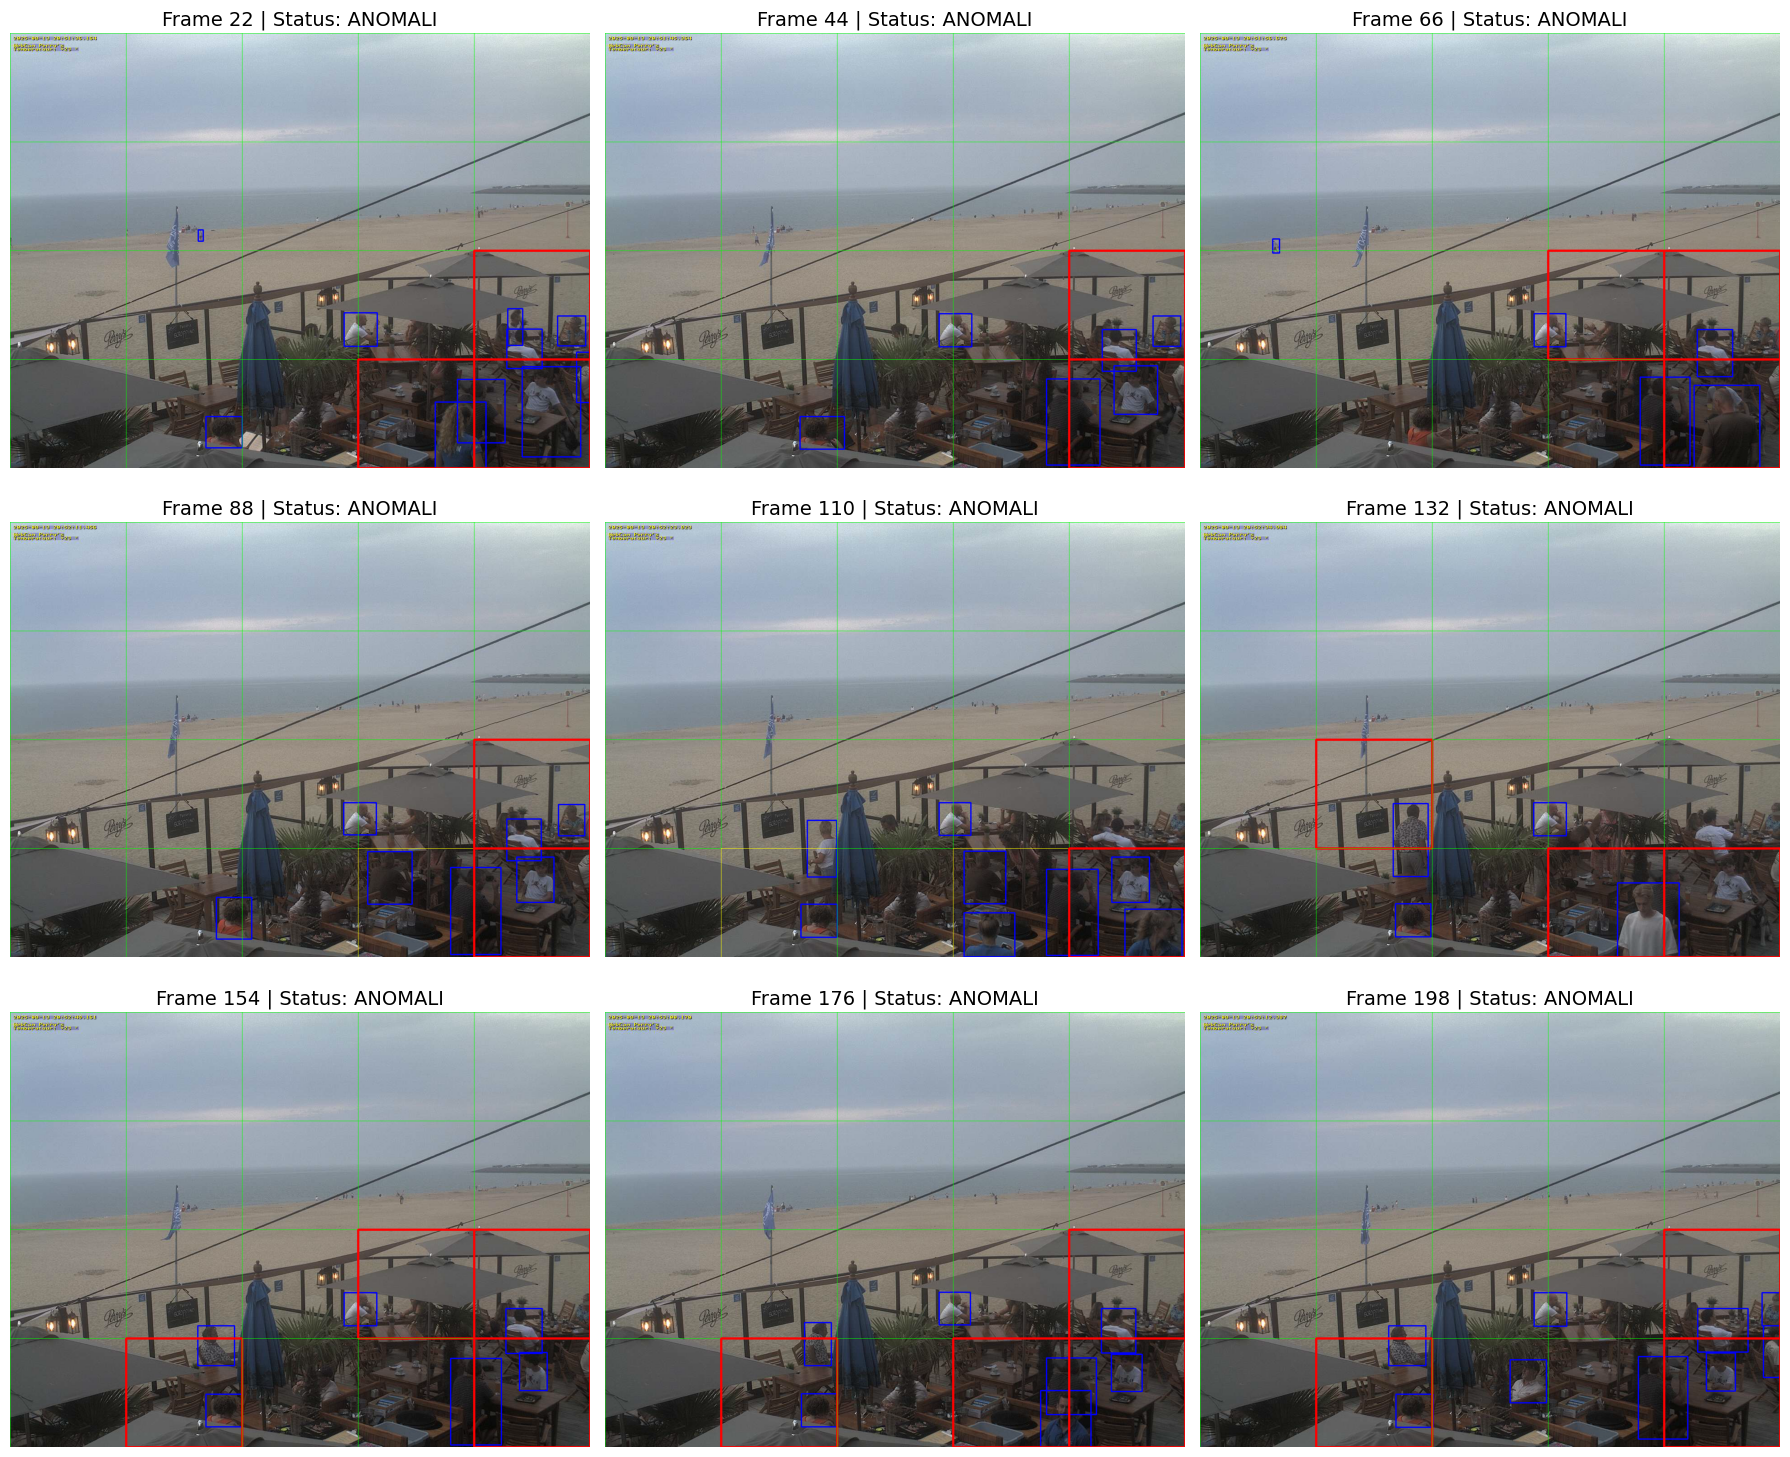

In [ ]:
# ======================================================================================
# SEL 2: DEMO REAL-TIME FINAL (Ringkas & Menggunakan Fungsi)
# ======================================================================================

# ... KODE INI SAMA SEPERTI JAWABAN SAYA SEBELUMNYA, TIDAK PERLU DIUBAH ...
# (Saya sertakan lagi di sini untuk kelengkapan)

print("\n"+"="*60); print("🎥 MEMULAI DEMO REAL-TIME (FINAL)".center(60)); print("="*60)
VIDEO_SOURCE = "http://217.63.79.153:8081/cgi-bin/faststream.jpg?stream=half&fps=15&rand=COUNTER"
MAX_FRAMES_TO_PROCESS = 200; OUTPUT_VIDEO_NAME = 'hasil_demo_final.mp4'

if 'model' not in locals(): print("❌ Model belum dimuat. Jalankan SEL 1.")
else:
    output_path = os.path.join(PATH_FOLDER_OUTPUT, OUTPUT_VIDEO_NAME)
    out_writer=None; frame_count=0; cell_start_time,cell_grace_counter,samples={},{},[] # Renamed cell_grace -> cell_grace_counter

    print(f"🎥 Mencoba membuka stream: {VIDEO_SOURCE}")
    try:
        cap = cv2.VideoCapture(VIDEO_SOURCE); fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS)>0 else 20
        if not cap.isOpened(): raise IOError("Gagal membuka stream.")

        while frame_count < MAX_FRAMES_TO_PROCESS:
            ret, frame = cap.read();
            if not ret: print("\nStream berakhir."); break
            frame_count += 1
            if out_writer is None:
                h,w,_=frame.shape; out_writer=cv2.VideoWriter(output_path,cv2.VideoWriter_fourcc(*'mp4v'),fps,(w,h)); print(f"✅ Merekam ke {output_path}")

            annotated_frame, is_anomaly, person_count = process_single_frame(frame, time.time(), (cell_start_time, cell_grace_counter))

            status,color =("STATUS: ANOMALI!",(0,0,255)) if is_anomaly else("STATUS: AMAN",(0,255,0))
            cv2.putText(annotated_frame,status,(10,40),cv2.FONT_HERSHEY_SIMPLEX,1,color,2)
            cv2.putText(annotated_frame,f"Total Orang: {person_count}",(10,80),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,255),2)
            out_writer.write(annotated_frame)
            print(f"Frame #{frame_count}/{MAX_FRAMES_TO_PROCESS} | Status: {'ANOMALI' if is_anomaly else 'Aman'}")

            if (frame_count % max(1,MAX_FRAMES_TO_PROCESS//9)==0) and (len(samples)<9):
                samples.append({"image":cv2.cvtColor(annotated_frame.copy(),cv2.COLOR_BGR2RGB),"title":f"Frame {frame_count} | {'ANOMALI' if is_anomaly else 'Aman'}"})

    except(KeyboardInterrupt,IOError) as e: print(f"\n⏹️ Proses dihentikan: {e}")
    finally:
        if 'cap' in locals() and cap.isOpened():cap.release()
        if out_writer is not None:out_writer.release()
        print("\n🏁 Demo Selesai.");
        if os.path.exists(output_path): print(f"✅ Video hasil disimpan di: {output_path}")
        display_sample_grid(samples)

In [ ]:
    #     'video_uji_anomali_1.mp4': [(4, 14)],
    # 'video_uji_anomali_2.mp4': [(4,8)],
    # 'video_uji_anomali_3.mp4': [(4, 10)],
    # 'video_uji_anomali_4.mp4': [(9, 17)],
    # 'video_uji_normal_2.mp4': [],

In [14]:
# =============================================================
# SEL 1: SETUP, KONFIGURASI, DAN PUSAT FUNGSI (FINAL v4)
# =============================================================

# --- Instalasi dan Impor Library ---
print("📦 Menginstal/Memeriksa library yang dibutuhkan...");
!pip install ultralytics pandas openpyxl -q
import os, cv2, pandas as pd, time, numpy as np, matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import drive
print("✅ Library berhasil diimpor.")
drive.mount('/content/drive'); print("✅ Google Drive berhasil terhubung.")

# --- KONFIGURASI GLOBAL ---
print("\n⚙️ Memuat konfigurasi global...")
PATH_MODEL_TERBAIK = 'yolov8l.pt'
PATH_FOLDER_OUTPUT = '/content/drive/MyDrive/Magang KP Model AI/Model Anomaly - Crowd/Hasil Akhir Profesional/'
os.makedirs(PATH_FOLDER_OUTPUT, exist_ok=True)
# --- Parameter Tuning Utama ---
GRID_ROWS,GRID_COLS=4,5; CROWD_THRESHOLD_PER_CELL=2; ANOMALY_DURATION_SECONDS=3; MIN_ANOMALY_CELLS_FOR_ALARM=1;
CONFIDENCE_THRESHOLD=0.4; IMG_SIZE=640; GRACE_PERIOD_FRAMES=10

# --- Pemuatan Model (Dibuat Global) ---
try:
    model=YOLO(PATH_MODEL_TERBAIK); person_class_id=[k for k, v in model.names.items() if v.lower() == 'person'][0]
    print(f"✅ Model '{PATH_MODEL_TERBAIK}' dimuat."); print(f"   - Folder output: {PATH_FOLDER_OUTPUT}")
except Exception as e: print(f"❌ Gagal memuat model: {e}"); exit()

# =================================================================
# === PUSAT FUNGSI (Dengan Perbaikan Typo `dur` -> `duration`) ===
# =================================================================

def process_single_frame(frame, time_reference, state_vars):
    annotated_frame = frame.copy()
    cell_start_time, cell_grace_counter = state_vars
    detections = model.predict(annotated_frame, classes=[person_class_id], conf=CONFIDENCE_THRESHOLD, imgsz=IMG_SIZE, verbose=False)

    people_in_grid = np.zeros((GRID_ROWS,GRID_COLS),dtype=int)
    grid_w, grid_h = frame.shape[1]//GRID_COLS, frame.shape[0]//GRID_ROWS

    for box in detections[0].boxes:
        x1,y1,x2,y2 = map(int,box.xyxy[0]); conf=float(box.conf[0])
        cv2.rectangle(annotated_frame,(x1,y1),(x2,y2),(255,0,0),2)
        label = f"Person ({conf*100:.1f}%)"; cv2.putText(annotated_frame,label,(x1,y1-10),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,0,0),2)
        cx,cy=int((x1+x2)/2),int((y1+y2)/2); col,row=min(cx//grid_w,GRID_COLS-1),min(cy//grid_h,GRID_ROWS-1); people_in_grid[row,col]+=1

    anomaly_cells_count = 0
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            cid=(r,c); is_crowded=people_in_grid[r,c]>=CROWD_THRESHOLD_PER_CELL; color=(0,255,0); is_anomaly=False
            x1c,y1c,x2c,y2c=c*grid_w,r*grid_h,(c+1)*grid_w,(r+1)*grid_h
            if is_crowded:
                if cid in cell_grace_counter: del cell_grace_counter[cid]
                if cid not in cell_start_time: cell_start_time[cid]=time_reference
                duration=time_reference-cell_start_time[cid];color=(0,255,255)
                # === FIX DI SINI ===
                if duration >= ANOMALY_DURATION_SECONDS: anomaly_cells_count+=1;is_anomaly=True;color=(0,0,255)
                # ===================
            elif cid in cell_start_time:
                if cid not in cell_grace_counter:cell_grace_counter[cid]=0
                cell_grace_counter[cid]+=1
                duration=time_reference-cell_start_time[cid];color=(0,255,255)
                # === DAN FIX DI SINI ===
                if duration >= ANOMALY_DURATION_SECONDS:anomaly_cells_count+=1;is_anomaly=True;color=(0,0,255)
                # =======================
                if cell_grace_counter[cid]>GRACE_PERIOD_FRAMES:del cell_start_time[cid];del cell_grace_counter[cid]
            cv2.rectangle(annotated_frame,(x1c,y1c),(x2c,y2c),color,3 if is_anomaly else 1)

    is_overall_anomaly=anomaly_cells_count>=MIN_ANOMALY_CELLS_FOR_ALARM
    person_count=len(detections[0].boxes)
    return annotated_frame, is_overall_anomaly, person_count

def display_sample_grid(sample_data):
    if not sample_data: print("Tidak ada gambar sampel."); return
    cols=min(len(sample_data),4); rows=(len(sample_data)+cols-1)//cols
    plt.figure(figsize=(cols*5,rows*4));
    for i,d in enumerate(sample_data): plt.subplot(rows,cols,i+1); plt.imshow(d["image"]); plt.title(d["title"],fontsize=12); plt.axis('off')
    plt.tight_layout(); plt.show()

print("\n✅ Setup dan fungsi-fungsi inti siap digunakan.")

📦 Menginstal/Memeriksa library yang dibutuhkan...
✅ Library berhasil diimpor.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil terhubung.

⚙️ Memuat konfigurasi global...
✅ Model 'yolov8l.pt' dimuat.
   - Folder output: /content/drive/MyDrive/Magang KP Model AI/Model Anomaly - Crowd/Hasil Akhir Profesional/

✅ Setup dan fungsi-fungsi inti siap digunakan.



         🔍 MEMULAI PROSES VALIDASI AKURASI (FINAL)          

--- Memvalidasi video: video_uji_anomali_1.mp4 ---
  -> Ringkasan: Bagus
  -> Video validasi disimpan.


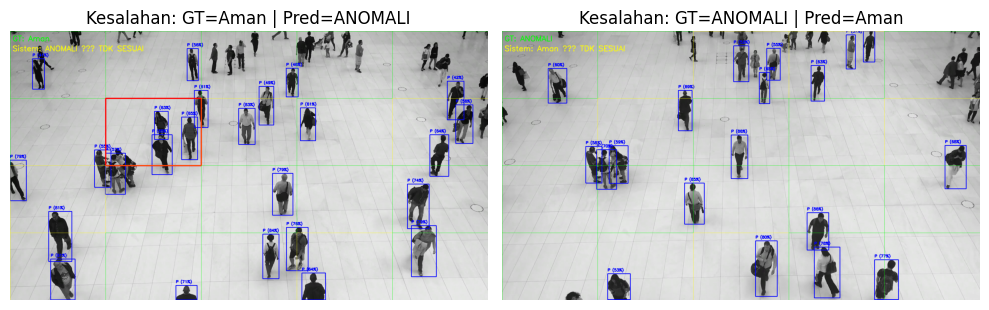


--- Memvalidasi video: video_uji_normal_2.mp4 ---
  -> Ringkasan: AlarmPalsu
  -> Video validasi disimpan.
Tidak ada gambar sampel.

--- Memvalidasi video: video_uji_anomali_2.mp4 ---
  -> Ringkasan: Bagus
  -> Video validasi disimpan.


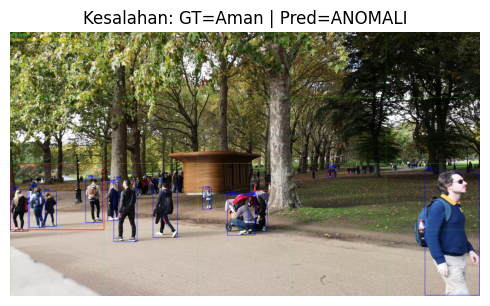


--- Memvalidasi video: video_uji_anomali_3.mp4 ---
  -> Ringkasan: Bagus
  -> Video validasi disimpan.


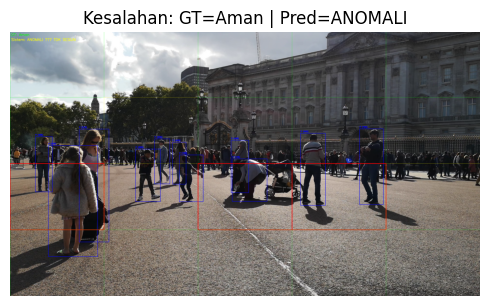


--- Memvalidasi video: video_uji_anomali_4.mp4 ---
  -> Ringkasan: Bagus
  -> Video validasi disimpan.


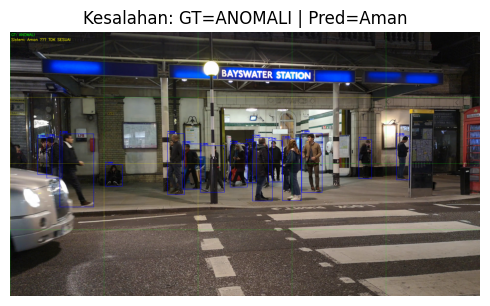


                         📋 RINGKASAN VALIDASI PER VIDEO                         
             Nama Video TP(detik) FN(detik) FP(detik) TN(detik) Kesimpulan
video_uji_anomali_1.mp4       10d        1d        1d        3d      Bagus
 video_uji_normal_2.mp4        0d        0d        0d       17d AlarmPalsu
video_uji_anomali_2.mp4        4d        1d        1d        3d      Bagus
video_uji_anomali_3.mp4        7d        0d        1d        4d      Bagus
video_uji_anomali_4.mp4        7d        2d        0d        9d      Bagus

                          📊 HASIL AKURASI KESELURUHAN                           
🎯 Precision: 90.32% | 🎯 Recall: 87.50% | 🏆 F1-SCORE: 0.8889
✅ Laporan lengkap berhasil disimpan ke: /content/drive/MyDrive/Magang KP Model AI/Model Anomaly - Crowd/Hasil Akhir Profesional/laporan_akurasi_crowd_final.xlsx


In [15]:
# ========================================================================================
# SEL 3: VALIDASI AKURASI FINAL v2.1 (FIX: State Direset untuk Setiap Video)
# ========================================================================================

print("\n" + "="*60); print("🔍 MEMULAI PROSES VALIDASI AKURASI (FINAL)".center(60)); print("="*60)
PATH_FOLDER_VIDEO_UJI='/content/drive/MyDrive/Magang KP Model AI/Model Anomaly - Crowd/Video Uji Anomali/'; os.makedirs(PATH_FOLDER_VIDEO_UJI, exist_ok=True)
GROUND_TRUTH_EVENTS = {
    'video_uji_anomali_1.mp4': [(4, 14)],
    'video_uji_anomali_2.mp4': [(4,8)],
    'video_uji_anomali_3.mp4': [(4, 10)],
    'video_uji_anomali_4.mp4': [(9, 17)],
    'video_uji_normal_2.mp4': [],
}

if 'model' not in locals(): print("❌ Model belum dimuat. Jalankan SEL 1.")
else:
    total_TP,total_FP,total_TN,total_FN=0,0,0,0; validation_summary=[]
    video_files=[f for f in os.listdir(PATH_FOLDER_VIDEO_UJI) if f in GROUND_TRUTH_EVENTS]
    if not video_files: print("⚠️ Folder video uji kosong.")
    else:
        for video_name in video_files:
            print(f"\n--- Memvalidasi video: {video_name} ---")
            vid_path,out_vid_path=os.path.join(PATH_FOLDER_VIDEO_UJI,video_name),os.path.join(PATH_FOLDER_OUTPUT,f"hasil_validasi_{video_name}")
            cap=cv2.VideoCapture(vid_path);fps=cap.get(cv2.CAP_PROP_FPS);total_frames,total_sec=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),int(cap.get(cv2.CAP_PROP_FRAME_COUNT))/fps
            h,w=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),int(cap.get(cv2.CAP_PROP_FRAME_WIDTH));out_writer=cv2.VideoWriter(out_vid_path,cv2.VideoWriter_fourcc(*'mp4v'),fps,(w,h))
            gt_timeline,pred_timeline=np.zeros(int(total_sec)+2,dtype=int),np.zeros(int(total_sec)+2,dtype=int)
            for s,e in GROUND_TRUTH_EVENTS[video_name]: gt_timeline[s:e+1]=1

            # === PERBAIKAN PENTING DI SINI ===
            # Inisialisasi state_vars di DALAM loop video, agar bersih setiap saat.
            frame_idx, cell_start_time, cell_grace_counter, samples = 0, {}, {}, []
            # =================================

            while True:
                ret, frame = cap.read();
                if not ret: break
                frame_idx+=1; time_in_vid=frame_idx/fps
                current_time_absolute = time.time() # Gunakan time.time() untuk durasi real, bukan time_in_vid

                # --- Modifikasi kecil di pemanggilan fungsi ---
                # Mengganti `time.time()` dengan `time_in_vid` untuk state logic
                # Ini memastikan durasi dihitung berdasarkan waktu video, bukan waktu proses.
                model_params=(model,person_class_id,CONFIDENCE_THRESHOLD,IMG_SIZE)
                logic_params=(GRID_ROWS,GRID_COLS,CROWD_THRESHOLD_PER_CELL,ANOMALY_DURATION_SECONDS,GRACE_PERIOD_FRAMES)

                # Proses single frame (kita duplikasi fungsinya di sini untuk kejelasan)
                annotated_frame = frame.copy()
                detections = model.predict(frame, classes=[person_class_id], conf=CONFIDENCE_THRESHOLD, imgsz=IMG_SIZE, verbose=False)
                people_in_grid = np.zeros((GRID_ROWS, GRID_COLS), dtype=int)
                anomaly_cells_count = 0
                grid_w, grid_h = frame.shape[1] // GRID_COLS, frame.shape[0] // GRID_ROWS
                for box in detections[0].boxes:
                    x1,y1,x2,y2=map(int,box.xyxy[0]);conf=float(box.conf[0])
                    cv2.rectangle(annotated_frame,(x1,y1),(x2,y2),(255,0,0),2)
                    cv2.putText(annotated_frame,f"P ({conf*100:.0f}%)",(x1,y1-10),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,0,0),2)
                    cx,cy=int((x1+x2)/2),int((y1+y2)/2);col,row=min(cx//grid_w,GRID_COLS-1),min(cy//grid_h,GRID_ROWS-1);people_in_grid[row,col]+=1
                for r in range(GRID_ROWS):
                    for c in range(GRID_COLS):
                        cid=(r,c);is_crowded=people_in_grid[r,c]>=CROWD_THRESHOLD_PER_CELL;color=(0,255,0);is_anomaly_cell=False
                        x1c,y1c,x2c,y2c = c*grid_w,r*grid_h,(c+1)*grid_w,(r+1)*grid_h
                        if is_crowded:
                            if cid in cell_grace_counter: del cell_grace_counter[cid]
                            if cid not in cell_start_time: cell_start_time[cid]=time_in_vid
                            dur=time_in_vid-cell_start_time[cid];color=(0,255,255)
                            if dur>=ANOMALY_DURATION_SECONDS: anomaly_cells_count+=1;is_anomaly_cell=True;color=(0,0,255)
                        elif cid in cell_start_time:
                            if cid not in cell_grace_counter: cell_grace_counter[cid]=0
                            cell_grace_counter[cid]+=1; dur=time_in_vid-cell_start_time[cid];color=(0,255,255)
                            if dur>=ANOMALY_DURATION_SECONDS: anomaly_cells_count+=1;is_anomaly_cell=True;color=(0,0,255)
                            if cell_grace_counter[cid]>GRACE_PERIOD_FRAMES:del cell_start_time[cid];del cell_grace_counter[cid]
                        cv2.rectangle(annotated_frame,(x1c,y1c),(x2c,y2c),color,3 if is_anomaly_cell else 1)
                is_anomaly = anomaly_cells_count>=MIN_ANOMALY_CELLS_FOR_ALARM
                # --- Akhir duplikasi fungsi ---

                current_sec=int(time_in_vid)
                if is_anomaly: pred_timeline[current_sec]=1

                gt_stat, pred_stat=("ANOMALI" if gt_timeline[current_sec]==1 else "Aman"),("ANOMALI" if is_anomaly else "Aman")
                match = "✅ SESUAI" if gt_stat == pred_stat else "❌ TDK SESUAI"
                cv2.putText(annotated_frame,f"GT: {gt_stat}",(10,40),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),2)
                cv2.putText(annotated_frame,f"Sistem: {pred_stat} {match}",(10,80),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,255),2)
                out_writer.write(annotated_frame)

                if (match == "❌ TDK SESUAI" and len(samples) < 4):
                     # Ambil sampel hanya jika state kesalahannya berbeda dari sampel terakhir, untuk variasi
                     if not samples or samples[-1]['title'] != f"Kesalahan: GT={gt_stat} | Pred={pred_stat}":
                        samples.append({"image":cv2.cvtColor(annotated_frame.copy(),cv2.COLOR_BGR2RGB),"title":f"Kesalahan: GT={gt_stat} | Pred={pred_stat}"})

            # Logika ringkasan (tidak berubah)
            TP,FP,TN,FN=np.sum((pred_timeline==1)&(gt_timeline==1)),np.sum((pred_timeline==1)&(gt_timeline==0)),np.sum((pred_timeline==0)&(gt_timeline==0)),np.sum((pred_timeline==0)&(gt_timeline==1))
            kesimpulan="Sempurna!" if(FP==0 and FN==0 and TP>0) else "Bagus" if(TP>FN and FP<TP) else "Miss" if(FN>TP) else "AlarmPalsu"
            validation_summary.append([video_name,f"{TP}d",f"{FN}d",f"{FP}d",f"{TN}d",kesimpulan])
            total_TP+=TP;total_FP+=FP;total_TN+=TN;total_FN+=FN
            print(f"  -> Ringkasan: {kesimpulan}");print(f"  -> Video validasi disimpan.");out_writer.release();cap.release()
            display_sample_grid(samples) # Memanggil fungsi dari Sel 1

    # Laporan Akhir (tidak berubah)
    # ... (sisanya sama persis) ...
    report_df=pd.DataFrame(validation_summary,columns=["Nama Video","TP(detik)","FN(detik)","FP(detik)","TN(detik)","Kesimpulan"]);print("\n"+"="*80);print("📋 RINGKASAN VALIDASI PER VIDEO".center(80));print("="*80);print(report_df.to_string(index=False));print("\n"+"="*80);print("📊 HASIL AKURASI KESELURUHAN".center(80));print("="*80)
    try:
        precision,recall,f1_score=(total_TP/(total_TP+total_FP)if(total_TP+total_FP)>0 else 0,total_TP/(total_TP+total_FN)if(total_TP+total_FN)>0 else 0,0);
        if(precision+recall)>0: f1_score=2*(precision*recall)/(precision+recall);print(f"🎯 Precision: {precision:.2%} | 🎯 Recall: {recall:.2%} | 🏆 F1-SCORE: {f1_score:.4f}");
        agg_df=pd.DataFrame([{"Precision":f"{precision:.2%}", "Recall":f"{recall:.2%}", "F1-Score":f"{f1_score:.4f}", "TP":total_TP, "FP":total_FP, "TN":total_TN, "FN":total_FN}])
        excel_path=os.path.join(PATH_FOLDER_OUTPUT,'laporan_akurasi_crowd_final.xlsx');
        with pd.ExcelWriter(excel_path,engine='openpyxl') as writer:agg_df.to_excel(writer,sheet_name='Ringkasan',index=False);report_df.to_excel(writer,sheet_name='Detail per Video',index=False);
        print(f"✅ Laporan lengkap berhasil disimpan ke: {excel_path}")
    except Exception as e: print(f"❌ Error saat hitung akurasi: {e}")

In [7]:
# =======================================================================
# SEL 4: EKSPOR MODEL KE TFLite (FIX FINAL - Menggunakan shutil.move)
# =======================================================================
import shutil # <-- PASTIKAN LIBRARY INI DI-IMPORT

print("\n" + "="*60); print("🚀 MEMULAI PROSES EKSPOR MODEL KE TFLITE".center(60)); print("="*60)

if 'model' not in locals():
    print("❌ Model belum dimuat. Jalankan SEL 1 terlebih dahulu.")
else:
    print(f"Model sumber untuk ekspor: '{PATH_MODEL_TERBAIK}'")
    print(f"Hasil ekspor akan disimpan di folder: {PATH_FOLDER_OUTPUT}")

    # Menggunakan nama dasar dari model yang didefinisikan di Sel 1
    # Jika PATH_MODEL_TERBAIK adalah 'yolov8l.pt', maka model_name_base akan menjadi 'yolov8l'
    model_name_base = PATH_MODEL_TERBAIK.split('.')[0]

    # --- 1. Export ke TFLite (float32) ---
    try:
        print("\n(1/3) Mengekspor ke float32...")
        # Simpan sementara di Colab, dan tangkap path sementaranya
        temp_path = model.export(format='tflite', imgsz=IMG_SIZE, verbose=False)
        # Tentukan nama file akhir di Drive
        final_path = os.path.join(PATH_FOLDER_OUTPUT, f'{model_name_base}_float32.tflite')

        # === PERBAIKAN: Gunakan shutil.move() bukan os.rename() ===
        shutil.move(temp_path, final_path)

        print(f"✅ Ekspor float32 berhasil! Model disimpan di:\n   {final_path}")
    except Exception as e:
        print(f"❌ Gagal mengekspor float32: {e}")

    # --- 2. Export ke TFLite (float16) ---
    try:
        print("\n(2/3) Mengekspor ke float16...")
        temp_path = model.export(format='tflite', imgsz=IMG_SIZE, half=True, verbose=False)
        final_path = os.path.join(PATH_FOLDER_OUTPUT, f'{model_name_base}_float16.tflite')

        # === PERBAIKAN ===
        shutil.move(temp_path, final_path)

        print(f"✅ Ekspor float16 berhasil! Model disimpan di:\n   {final_path}")
    except Exception as e:
        print(f"❌ Gagal mengekspor float16: {e}")

    # --- 3. Export ke TFLite (int8) ---
    try:
        print("\n(3/3) Mengekspor ke int8...")
        temp_path = model.export(format='tflite', imgsz=IMG_SIZE, int8=True, verbose=False)
        final_path = os.path.join(PATH_FOLDER_OUTPUT, f'{model_name_base}_int8.tflite')

        # === PERBAIKAN ===
        shutil.move(temp_path, final_path)

        print(f"✅ Ekspor int8 berhasil! Model disimpan di:\n   {final_path}")
    except Exception as e:
        print(f"❌ Gagal mengekspor int8: {e}")

    print("\n🎉 Proses ekspor TFLite selesai!")
    print(f"Semua file telah berhasil disimpan langsung ke folder Google Drive Anda.")


          🚀 MEMULAI PROSES EKSPOR MODEL KE TFLITE           
Model sumber untuk ekspor: 'yolov8l.pt'
Hasil ekspor akan disimpan di folder: /content/drive/MyDrive/Magang KP Model AI/Model Anomaly - Crowd/Hasil Akhir Profesional/

(1/3) Mengekspor ke float32...
Ultralytics 8.3.178 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.00GHz)

PyTorch: starting from 'yolov8l.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (83.7 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.64...
ONNX: export success ✅ 11.6s, saved as 'yolov8l.onnx' (166.9 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.2...
Saved artifact at 'yolov8l_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 84, 

Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]

WARNING ⚠️ TensorFlow SavedModel: >300 images recommended for INT8 calibration, found 4 images.


TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.2...
Saved artifact at 'yolov8l_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 84, 8400), dtype=tf.float32, name=None)
Captures:
  135673061761360: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  135673061761936: TensorSpec(shape=(3, 3, 3, 64), dtype=tf.float32, name=None)
  135673061760592: TensorSpec(shape=(64,), dtype=tf.float32, name=None)
  135676951452688: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  135676951454800: TensorSpec(shape=(3, 3, 64, 128), dtype=tf.float32, name=None)
  135676951452880: TensorSpec(shape=(128,), dtype=tf.float32, name=None)
  135676951455184: TensorSpec(shape=(1, 1, 128, 128), dtype=tf.float32, name=None)
  135673072966096: TensorSpec(shape=(128,), dtype=tf.float32, name=None)
  135673072965904: TensorSpec(sh